# 03 — Modelos clásicos de Machine Learning

**Caso de uso:** Predicción de Diagnóstico de Cáncer  
**Asignatura:** Inteligencia Artificial — UAX 2025/2026  
**Autor:** Álvaro Santamaría Antón

## Propósito

Entrenar y comparar **4 modelos clásicos de ML** sobre el dataset preparado en la Fase 2:

1. **Regresión Logística** — baseline lineal con regularización L2
2. **Random Forest** — bagging de árboles
3. **XGBoost** — gradient boosting (eXtreme Gradient Boosting)
4. **LightGBM** — gradient boosting de Microsoft

Todos los modelos usan `class_weight='balanced'` (o `scale_pos_weight` equivalente) para gestionar el desbalance del 80/20.

## Métricas evaluadas (sobre validación)

- **Precisión** — proporción de predicciones positivas que son correctas
- **Recall** — proporción de casos de cáncer reales que el modelo detecta
- **F1-Score** — media armónica de las dos anteriores (métrica principal)
- **AUC-ROC** — área bajo la curva ROC
- **Accuracy** — solo como referencia (en problemas desbalanceados es engañosa)

## Notas técnicas

- El umbral de decisión se fija en **0.5** para todos los modelos clásicos. La optimización del umbral se hará solo para la MLP (Fase 7), siguiendo el procedimiento del PDF.
- La evaluación se hace sobre **validación**, nunca sobre test. Test se reserva para la comparativa final (Fase 8).
- Todos los resultados se persisten en `models/results_ml.joblib` para reutilizar en Fase 8.

## Imports y carga de datos

In [1]:
import sys
import time
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

# Silenciar warnings benignos de LightGBM/sklearn al evaluar con arrays escalados
warnings.filterwarnings("ignore", message=".*does not have valid feature names.*")
warnings.filterwarnings("ignore", category=FutureWarning)

# Path al raíz del proyecto para importar src/
PROJECT_ROOT = Path.cwd().parent
sys.path.insert(0, str(PROJECT_ROOT))

from src.preprocessing import load_splits
from src.models_ml import get_all_ml_models
from src.evaluation import (
    evaluate_model_full,
    compare_models,
    plot_confusion_matrix,
    plot_roc_curves,
    plot_pr_curves,
    plot_metrics_comparison,
)

# Configuración visual
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.figsize"] = (10, 5)

FIGURES_DIR = PROJECT_ROOT / "reports" / "figures"
MODELS_DIR  = PROJECT_ROOT / "models"
MODELS_DIR.mkdir(exist_ok=True)

# === Cargar splits procesados ===
print("Cargando datos procesados...")
data = load_splits()

X_train, y_train = data["X_train"], data["y_train"]
X_val,   y_val   = data["X_val"],   data["y_val"]
X_test,  y_test  = data["X_test"],  data["y_test"]
feature_names    = data["feature_names"]
class_weights    = data["class_weights"]

print(f"  X_train: {X_train.shape}   y_train positivos: {y_train.sum()}/{len(y_train)} ({y_train.mean()*100:.2f}%)")
print(f"  X_val  : {X_val.shape}     y_val   positivos: {y_val.sum()}/{len(y_val)} ({y_val.mean()*100:.2f}%)")
print(f"  X_test : {X_test.shape}    y_test  positivos: {y_test.sum()}/{len(y_test)} ({y_test.mean()*100:.2f}%)")
print(f"\n  Class weights: {class_weights}")

# scale_pos_weight para XGBoost y LightGBM
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
print(f"  scale_pos_weight (n_neg/n_pos): {scale_pos_weight:.4f}")

Cargando datos procesados...
  X_train: (30000, 21)   y_train positivos: 5786/30000 (19.29%)
  X_val  : (10000, 21)     y_val   positivos: 1929/10000 (19.29%)
  X_test : (10001, 21)    y_test  positivos: 1929/10001 (19.29%)

  Class weights: {0: 0.6194763360039647, 1: 2.5924645696508812}
  scale_pos_weight (n_neg/n_pos): 4.1849


## Entrenamiento de los 4 modelos

In [2]:
# === Instanciar los 4 modelos ===
models = get_all_ml_models(scale_pos_weight=scale_pos_weight)

print("Modelos a entrenar:")
for name in models:
    print(f"  - {name}")

# === Entrenar cada modelo y medir tiempo ===
print("\n" + "=" * 60)
print("  ENTRENANDO MODELOS")
print("=" * 60)

trained_models = {}
training_times = {}

for name, model in models.items():
    t0 = time.time()
    model.fit(X_train, y_train)
    elapsed = time.time() - t0
    trained_models[name] = model
    training_times[name] = elapsed
    print(f"  ✓ {name:25s} entrenado en {elapsed:>6.2f} s")

print(f"\n  Tiempo total de entrenamiento: {sum(training_times.values()):.2f} s")

Modelos a entrenar:
  - Logistic Regression
  - Random Forest
  - XGBoost
  - LightGBM

  ENTRENANDO MODELOS
  ✓ Logistic Regression       entrenado en   0.02 s
  ✓ Random Forest             entrenado en   1.59 s
  ✓ XGBoost                   entrenado en   1.04 s
  ✓ LightGBM                  entrenado en   0.94 s

  Tiempo total de entrenamiento: 3.59 s


## Evaluación en validación

In [3]:
# === Evaluar cada modelo en validación ===
print("=" * 60)
print("  EVALUACIÓN EN VALIDACIÓN (threshold = 0.5)")
print("=" * 60)

results_val = {}
for name, model in trained_models.items():
    metrics = evaluate_model_full(model, X_val, y_val, threshold=0.5)
    results_val[name] = metrics
    print(f"\n  {name}:")
    print(f"    Precisión : {metrics['precision']:.4f}")
    print(f"    Recall    : {metrics['recall']:.4f}")
    print(f"    F1-Score  : {metrics['f1']:.4f}")
    print(f"    AUC-ROC   : {metrics['auc_roc']:.4f}")
    print(f"    Accuracy  : {metrics['accuracy']:.4f}")

  EVALUACIÓN EN VALIDACIÓN (threshold = 0.5)

  Logistic Regression:
    Precisión : 0.4142
    Recall    : 0.7237
    F1-Score  : 0.5269
    AUC-ROC   : 0.8207
    Accuracy  : 0.7493

  Random Forest:
    Precisión : 0.4214
    Recall    : 0.7050
    F1-Score  : 0.5275
    AUC-ROC   : 0.8166
    Accuracy  : 0.7564

  XGBoost:
    Precisión : 0.4584
    Recall    : 0.5775
    F1-Score  : 0.5111
    AUC-ROC   : 0.7939
    Accuracy  : 0.7869

  LightGBM:
    Precisión : 0.4392
    Recall    : 0.6200
    F1-Score  : 0.5142
    AUC-ROC   : 0.7999
    Accuracy  : 0.7740


## Tabla comparativa

In [4]:
# === Tabla comparativa ordenada por F1 ===
df_compare = compare_models(results_val)

print("=" * 70)
print("  RANKING DE MODELOS (ordenado por F1-Score en validación)")
print("=" * 70)
display(df_compare)

best_model_name = df_compare.iloc[0]["Modelo"]
best_metrics = results_val[best_model_name]

print(f"\n🏆 Mejor modelo ML: {best_model_name}")
print(f"   F1-Score:  {best_metrics['f1']:.4f}")
print(f"   AUC-ROC:   {best_metrics['auc_roc']:.4f}")
print(f"   Precisión: {best_metrics['precision']:.4f}")
print(f"   Recall:    {best_metrics['recall']:.4f}")

  RANKING DE MODELOS (ordenado por F1-Score en validación)


,Modelo,Precisión,Recall,F1-Score,AUC-ROC,Accuracy,Threshold
1,Random Forest,0.4214,0.7050,0.5275,0.8166,0.7564,0.5
2,Logistic Regression,0.4142,0.7237,0.5269,0.8207,0.7493,0.5
3,LightGBM,0.4392,0.6200,0.5142,0.7999,0.7740,0.5
4,XGBoost,0.4584,0.5775,0.5111,0.7939,0.7869,0.5



🏆 Mejor modelo ML: Random Forest
   F1-Score:  0.5275
   AUC-ROC:   0.8166
   Precisión: 0.4214
   Recall:    0.7050


## Visualizaciones comparativas

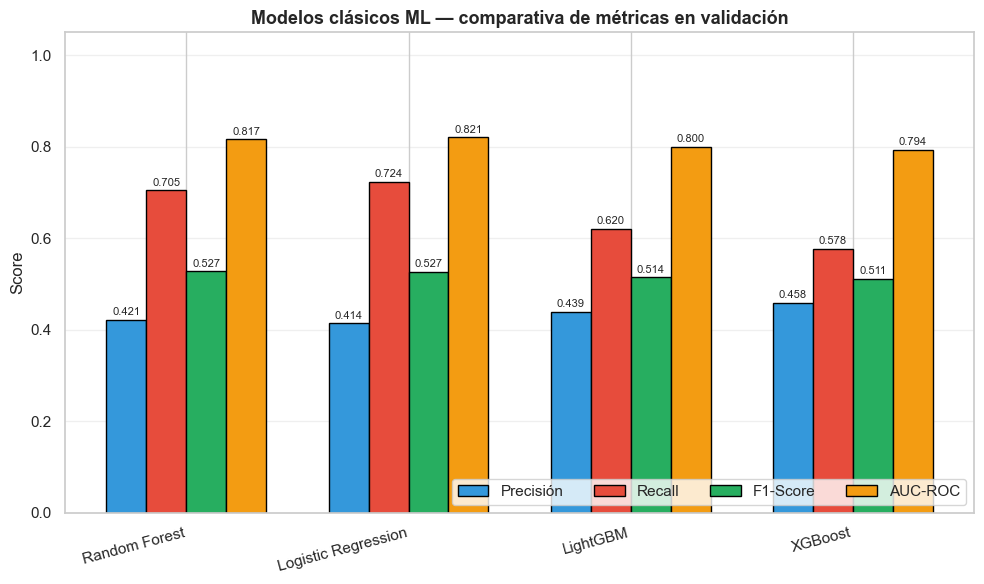

In [5]:
# === Gráfico de barras comparando las 4 métricas ===
plot_metrics_comparison(
    df_compare,
    title="Modelos clásicos ML — comparativa de métricas en validación",
    save_path=FIGURES_DIR / "12_ml_comparativa_metricas.png",
)
plt.show()

## Curvas ROC y PR superpuestas

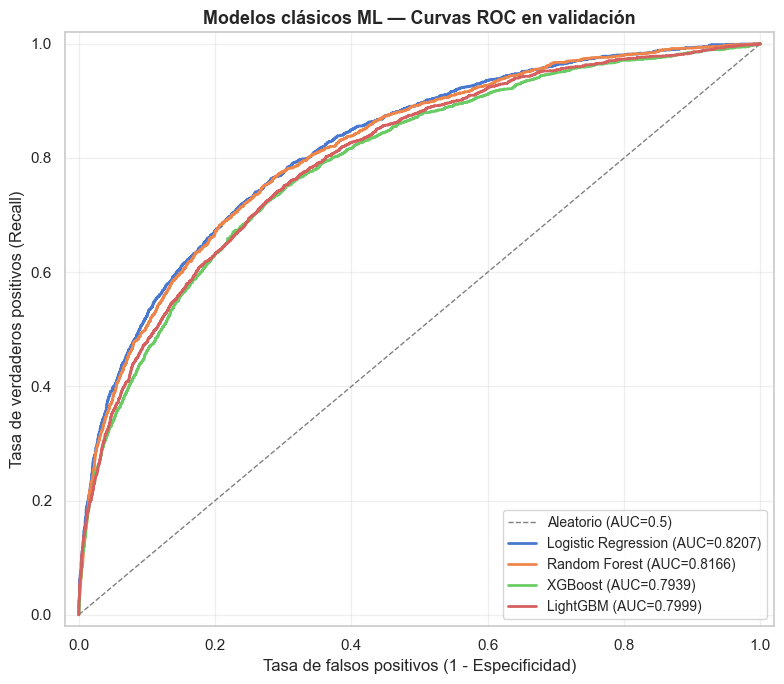

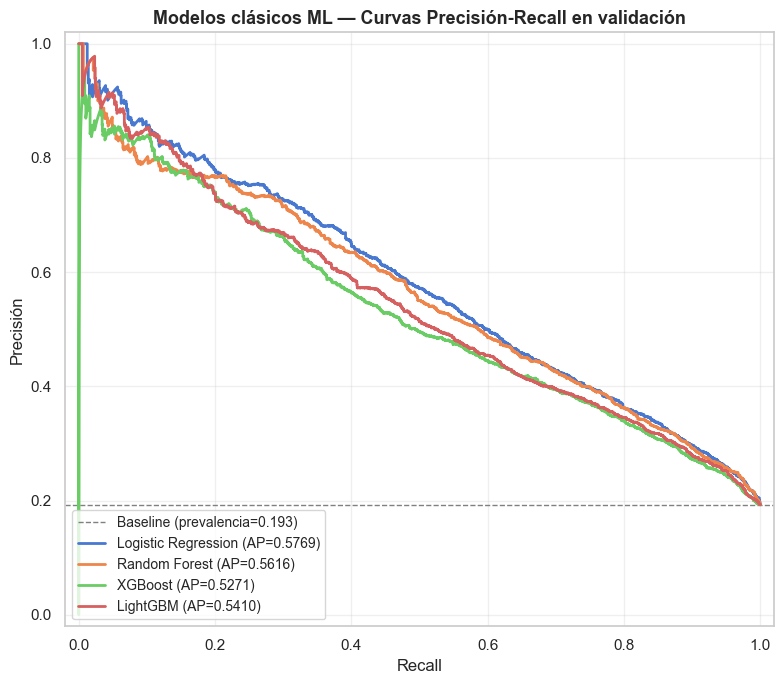

In [6]:
# === Curvas ROC ===
plot_roc_curves(
    results_val, y_val,
    title="Modelos clásicos ML — Curvas ROC en validación",
    save_path=FIGURES_DIR / "13_ml_roc_curves.png",
)
plt.show()

# === Curvas Precisión-Recall ===
plot_pr_curves(
    results_val, y_val,
    title="Modelos clásicos ML — Curvas Precisión-Recall en validación",
    save_path=FIGURES_DIR / "14_ml_pr_curves.png",
)
plt.show()

## Matriz de confusión del mejor modelo

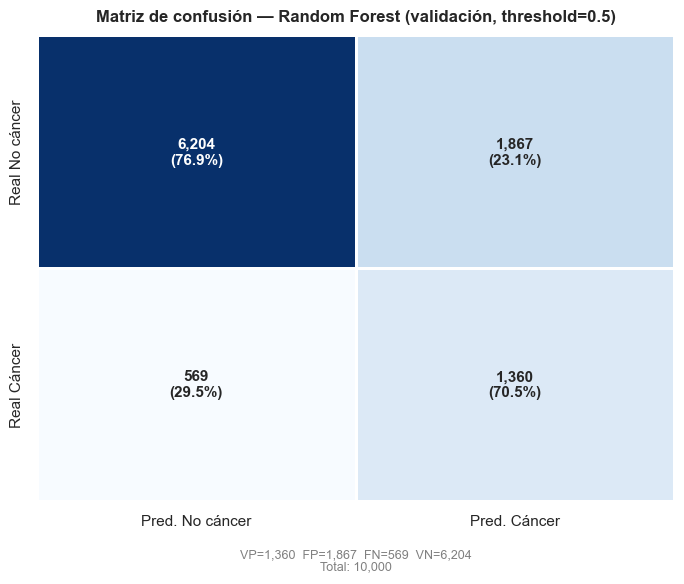


Lectura de la matriz de confusión (Random Forest):
  - 1,360 verdaderos positivos: pacientes con cáncer correctamente detectados
  - 569 falsos negativos: pacientes con cáncer NO detectados (recall = 70.5%)
  - 1,867 falsos positivos: pacientes sanos clasificados erróneamente como cáncer
  - 6,204 verdaderos negativos: pacientes sanos correctamente identificados

  En un cribado clínico real:
    Si llegasen 10,000 pacientes nuevos, el modelo señalaría a 3,227
    como sospechosos, de los cuales 1,360 (42.1%) tendrían cáncer.


In [7]:
# === Matriz de confusión del mejor modelo ===
fig, ax = plt.subplots(figsize=(7, 6))
plot_confusion_matrix(
    best_metrics["confusion_matrix"],
    title=f"Matriz de confusión — {best_model_name} (validación, threshold=0.5)",
    ax=ax,
)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "15_ml_best_confusion_matrix.png", dpi=120, bbox_inches="tight")
plt.show()

# Análisis textual de la matriz
tn, fp, fn, tp = best_metrics["confusion_matrix"].ravel()
total = tn + fp + fn + tp
n_real_pos = tp + fn

print(f"\nLectura de la matriz de confusión ({best_model_name}):")
print(f"  - {tp:,} verdaderos positivos: pacientes con cáncer correctamente detectados")
print(f"  - {fn:,} falsos negativos: pacientes con cáncer NO detectados (recall = {tp/(tp+fn)*100:.1f}%)")
print(f"  - {fp:,} falsos positivos: pacientes sanos clasificados erróneamente como cáncer")
print(f"  - {tn:,} verdaderos negativos: pacientes sanos correctamente identificados")
print(f"\n  En un cribado clínico real:")
print(f"    Si llegasen {total:,} pacientes nuevos, el modelo señalaría a {tp+fp:,}")
print(f"    como sospechosos, de los cuales {tp:,} ({tp/(tp+fp)*100:.1f}%) tendrían cáncer.")

## Importancia de features (de los modelos basados en árboles)

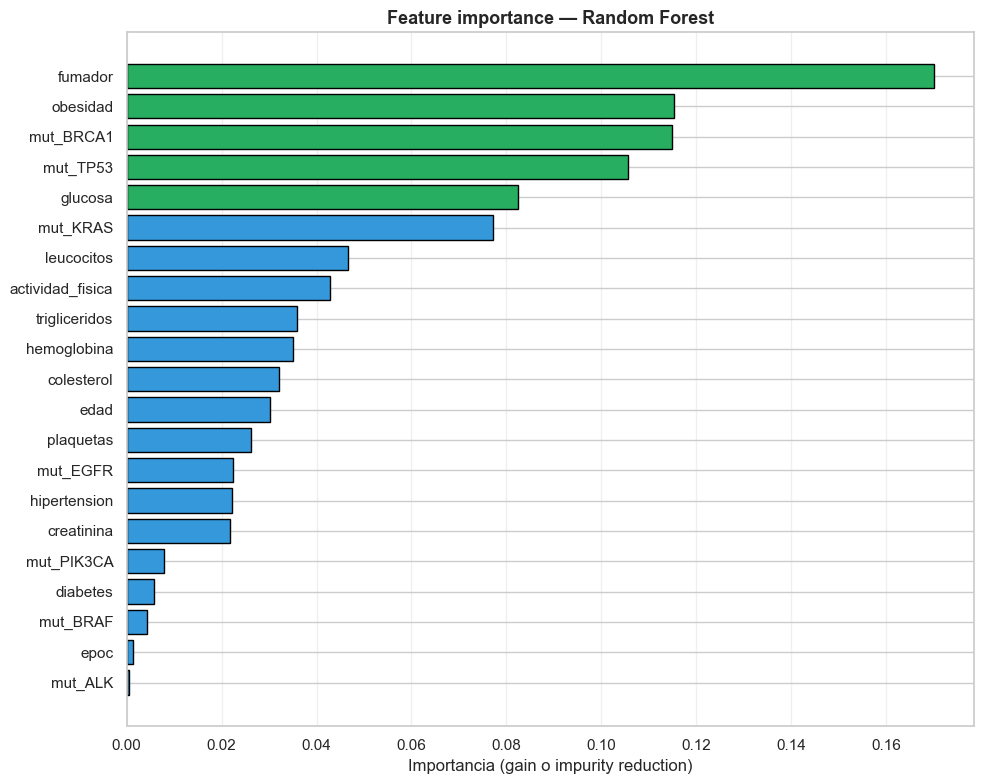


Top 5 features más importantes:
  fumador                    0.1700
  obesidad                   0.1154
  mut_BRCA1                  0.1148
  mut_TP53                   0.1057
  glucosa                    0.0825


In [8]:
# === Feature importance del mejor modelo (si es árbol) ===
best_model = trained_models[best_model_name]

if hasattr(best_model, "feature_importances_"):
    importances = pd.DataFrame({
        "feature": feature_names,
        "importance": best_model.feature_importances_,
    }).sort_values("importance", ascending=True)

    fig, ax = plt.subplots(figsize=(10, 8))
    colors = ["#27ae60" if i >= len(importances) - 5 else "#3498db"
              for i in range(len(importances))]
    ax.barh(importances["feature"], importances["importance"],
            color=colors, edgecolor="black")
    ax.set_xlabel("Importancia (gain o impurity reduction)")
    ax.set_title(f"Feature importance — {best_model_name}",
                 fontweight="bold", fontsize=13)
    ax.grid(axis="x", alpha=0.3)
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / "16_ml_feature_importance.png",
                dpi=120, bbox_inches="tight")
    plt.show()

    print("\nTop 5 features más importantes:")
    for _, row in importances.tail(5).iloc[::-1].iterrows():
        print(f"  {row['feature']:25s}  {row['importance']:.4f}")
elif hasattr(best_model, "coef_"):
    # Regresión Logística: usamos los coeficientes
    coefs = pd.DataFrame({
        "feature": feature_names,
        "coef": best_model.coef_[0],
        "abs_coef": np.abs(best_model.coef_[0]),
    }).sort_values("abs_coef", ascending=True)

    fig, ax = plt.subplots(figsize=(10, 8))
    colors = ["#e74c3c" if c < 0 else "#27ae60" for c in coefs["coef"]]
    ax.barh(coefs["feature"], coefs["coef"], color=colors, edgecolor="black")
    ax.axvline(x=0, color="black", linewidth=0.8)
    ax.set_xlabel("Coeficiente (positivo = aumenta riesgo)")
    ax.set_title(f"Coeficientes — {best_model_name} (regresión logística)",
                 fontweight="bold")
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / "16_ml_feature_importance.png",
                dpi=120, bbox_inches="tight")
    plt.show()

## Persistencia de resultados

In [9]:
# === Guardar todo lo necesario para la Fase 8 (comparativa final) ===

# 1. Modelos entrenados
for name, model in trained_models.items():
    safe_name = name.lower().replace(" ", "_")
    joblib.dump(model, MODELS_DIR / f"{safe_name}.joblib")

# 2. Resultados sobre validación (sin y_proba para no inflar el fichero)
results_serializable = {}
for name, m in results_val.items():
    results_serializable[name] = {
        k: v for k, v in m.items() if k != "y_proba"
    }
    # Las y_proba sí las guardamos aparte para curvas ROC/PR de la Fase 8
    results_serializable[name]["y_proba_val"] = m["y_proba"]

joblib.dump(results_serializable, MODELS_DIR / "results_ml_val.joblib")

# 3. Tabla comparativa
df_compare.to_csv(PROJECT_ROOT / "reports" / "ml_comparison_val.csv",
                  index=False)

print("=" * 60)
print("  FASE 3 COMPLETADA")
print("=" * 60)
print(f"  ✓ {len(trained_models)} modelos entrenados y evaluados")
print(f"  ✓ Mejor modelo: {best_model_name} (F1={best_metrics['f1']:.4f})")
print(f"  ✓ Modelos guardados en: {MODELS_DIR}")
print(f"  ✓ Resultados guardados en: {MODELS_DIR / 'results_ml_val.joblib'}")
print(f"  ✓ 5 figuras nuevas en: {FIGURES_DIR}")
print(f"\n  Listo para Fase 5: diseño y entrenamiento de la Red Neuronal MLP.")

  FASE 3 COMPLETADA
  ✓ 4 modelos entrenados y evaluados
  ✓ Mejor modelo: Random Forest (F1=0.5275)
  ✓ Modelos guardados en: c:\Users\alvar\Desktop\proyecto-cancer-ia\models
  ✓ Resultados guardados en: c:\Users\alvar\Desktop\proyecto-cancer-ia\models\results_ml_val.joblib
  ✓ 5 figuras nuevas en: c:\Users\alvar\Desktop\proyecto-cancer-ia\reports\figures

  Listo para Fase 5: diseño y entrenamiento de la Red Neuronal MLP.
